In [2]:
import numpy as np

prices = np.array([
    [100,108,103,115,110,119,125,121,130,127,135,140],  # Stock A
    [200,195,210,205,220,215,225,230,222,235,240,238]   # Stock B
])

# (a) Monthly simple returns — shape (2, 11)
returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]
print("Monthly Returns:\n", returns)
print("Shape:", returns.shape)   # (2, 11)

# (b) Annualised mean return and std deviation
mean_annual  = returns.mean(axis=1) * 12
std_annual   = returns.std(axis=1, ddof=1) * np.sqrt(12)
print("\nAnnualised Mean Return:", mean_annual)
print("Annualised Std Dev:    ", std_annual)

# (c) 2x2 sample covariance matrix
cov_matrix = np.cov(returns)   # ddof=1 by default
print("\nCovariance Matrix:\n", cov_matrix)

# Confirm off-diagonal = rho * sigA * sigB
rho    = np.corrcoef(returns)[0, 1]
sigA   = returns[0].std(ddof=1)
sigB   = returns[1].std(ddof=1)
manual = rho * sigA * sigB
print(f"\nrho*sigA*sigB = {manual:.6f}")
print(f"Cov[0,1]      = {cov_matrix[0,1]:.6f}")   # should match
import numpy as np

prices = np.array([
    [100,108,103,115,110,119,125,121,130,127,135,140],  # Stock A
    [200,195,210,205,220,215,225,230,222,235,240,238]   # Stock B
])

# (a) Monthly simple returns — shape (2, 11)
returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]
print("Monthly Returns:\n", returns)
print("Shape:", returns.shape)   # (2, 11)

# (b) Annualised mean return and std deviation
mean_annual  = returns.mean(axis=1) * 12
std_annual   = returns.std(axis=1, ddof=1) * np.sqrt(12)
print("\nAnnualised Mean Return:", mean_annual)
print("Annualised Std Dev:    ", std_annual)

# (c) 2x2 sample covariance matrix
cov_matrix = np.cov(returns)   # ddof=1 by default
print("\nCovariance Matrix:\n", cov_matrix)

# Confirm off-diagonal = rho * sigA * sigB
rho    = np.corrcoef(returns)[0, 1]
sigA   = returns[0].std(ddof=1)
sigB   = returns[1].std(ddof=1)
manual = rho * sigA * sigB
print(f"\nrho*sigA*sigB = {manual:.6f}")
print(f"Cov[0,1]      = {cov_matrix[0,1]:.6f}")   # should match


Monthly Returns:
 [[ 0.08       -0.0462963   0.11650485 -0.04347826  0.08181818  0.05042017
  -0.032       0.07438017 -0.02307692  0.06299213  0.03703704]
 [-0.025       0.07692308 -0.02380952  0.07317073 -0.02272727  0.04651163
   0.02222222 -0.03478261  0.05855856  0.0212766  -0.00833333]]
Shape: (2, 11)

Annualised Mean Return: [0.39087388 0.20073826]
Annualised Std Dev:     [0.20199403 0.14582022]

Covariance Matrix:
 [[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]

rho*sigA*sigB = -0.002064
Cov[0,1]      = -0.002064
Monthly Returns:
 [[ 0.08       -0.0462963   0.11650485 -0.04347826  0.08181818  0.05042017
  -0.032       0.07438017 -0.02307692  0.06299213  0.03703704]
 [-0.025       0.07692308 -0.02380952  0.07317073 -0.02272727  0.04651163
   0.02222222 -0.03478261  0.05855856  0.0212766  -0.00833333]]
Shape: (2, 11)

Annualised Mean Return: [0.39087388 0.20073826]
Annualised Std Dev:     [0.20199403 0.14582022]

Covariance Matrix:
 [[ 0.00340013 -0.00206426]
 [-0.00206426

In [3]:
import numpy as np

# Parameters from Q6
mu    = np.array([0.15, 0.08, 0.05])
sigma = np.array([0.25, 0.12, 0.04])
rho   = np.array([[1.0, 0.4, 0.1],
                   [0.4, 1.0, 0.2],
                   [0.1, 0.2, 1.0]])

# Build covariance matrix: Sigma_ij = rho_ij * sigma_i * sigma_j
Sigma = rho * np.outer(sigma, sigma)
print("Covariance Matrix:\n", Sigma)

# (a) Equal-weight portfolio
w = np.array([1/3, 1/3, 1/3])
Ep   = w @ mu                        # Expected return
Varp = w @ Sigma @ w                 # Variance
sigp = np.sqrt(Varp)
print(f"\nEqual-weight portfolio:")
print(f"  E[Rp] = {Ep:.4f}")
print(f"  sigma_p = {sigp:.4f}")

# (b) 10,000 random portfolios
np.random.seed(42)
W = np.random.dirichlet(np.ones(3), size=10000)  # shape (10000, 3)
rets = W @ mu                                     # shape (10000,)
vols = np.sqrt(np.einsum('ij,jk,ik->i', W, Sigma, W))  # shape (10000,)

# (c) Sharpe Ratios — vectorised, no loop
Rf      = 0.04
sharpes = (rets - Rf) / vols
best    = np.argmax(sharpes)

print(f"\nMax Sharpe Ratio : {sharpes[best]:.4f}")
print(f"Weights          : {W[best]}")
print(f"Return           : {rets[best]*100:.2f}%")
print(f"Volatility       : {vols[best]*100:.2f}%")


Covariance Matrix:
 [[0.0625  0.012   0.001  ]
 [0.012   0.0144  0.00096]
 [0.001   0.00096 0.0016 ]]

Equal-weight portfolio:
  E[Rp] = 0.0933
  sigma_p = 0.1087

Max Sharpe Ratio : 0.5053
Weights          : [0.20343152 0.17148749 0.62508099]
Return           : 7.55%
Volatility       : 7.02%


In [4]:
import numpy as np

# Parameters
mu1, mu2 = 0.12, 0.06
s1,  s2  = 0.20, 0.10
w1,  w2  = 0.60, 0.40

# (a) 200 correlation values — no loop
rho_arr = np.linspace(-1, 1, 200)

# Portfolio variance formula — fully vectorised
var_p = (w1**2 * s1**2
       + w2**2 * s2**2
       + 2 * w1 * w2 * rho_arr * s1 * s2)

sig_p = np.sqrt(var_p)          # shape (200,)
print("Shape of sig_p:", sig_p.shape)

# (b) Minimum sigma_p and the rho where it occurs
min_idx   = np.argmin(sig_p)
min_sigp  = sig_p[min_idx]
min_rho   = rho_arr[min_idx]
print(f"\nMinimum sigma_p = {min_sigp*100:.4f}%")
print(f"Occurs at rho   = {min_rho:.4f}")

# (c) Analytical verification:
# d(sigma_p^2)/d(rho) = 2*w1*w2*s1*s2  > 0  always
# So variance is strictly increasing in rho
# => minimum always at rho = -1 (left boundary)
print("\nAnalytical check:")
print("d(var_p)/d(rho) = 2*w1*w2*s1*s2 =",
      round(2*w1*w2*s1*s2, 6), "> 0 always")
print("=> var_p is increasing in rho => minimum at rho = -1")
print(f"sigma_p at rho=-1: {sig_p[0]*100:.4f}%")


Shape of sig_p: (200,)

Minimum sigma_p = 8.0000%
Occurs at rho   = -1.0000

Analytical check:
d(var_p)/d(rho) = 2*w1*w2*s1*s2 = 0.0096 > 0 always
=> var_p is increasing in rho => minimum at rho = -1
sigma_p at rho=-1: 8.0000%


In [5]:
import pandas as pd
import numpy as np

# Setup — given in question
np.random.seed(0)
dates       = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly   = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly  = np.array([0.04,  0.03,  0.02,  0.025 ])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim  = 100 * np.cumprod(1 + returns_sim, axis=0)
df = pd.DataFrame(prices_sim, index=dates,
                  columns=['AAPL','MSFT','GOOGL','AMZN'])

# (a) Weekly simple returns
df_ret = df.pct_change().dropna()
print("First 3 rows:\n", df_ret.head(3))
print("Shape:", df_ret.shape)   # (51, 4)

# (b) Descriptive statistics
desc = df_ret.describe()
print("\nDescribe:\n", desc)
print("\nHighest mean return :", df_ret.mean().idxmax())
print("Highest std deviation:", df_ret.std().idxmax())

# (c) Annualised Sharpe Ratio — no loops
Rf_weekly  = 0.02 / 52          # weekly risk-free rate
mean_ann   = df_ret.mean() * 52
std_ann    = df_ret.std()  * np.sqrt(52)
sharpe     = (mean_ann - 0.02) / std_ann   # Rf=2% annualised
print("\nAnnualised Sharpe Ratios:\n", sharpe)


First 3 rows:
                 AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842
Shape: (51, 4)

Describe:
             AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.002650  -0.000365   0.009468
75%     0.039082   0.028178   0.009462   0.020051
max     0.098326   0.060309   0.044265   0.050269

Highest mean return : AMZN
Highest std deviation: AAPL

Annualised Sharpe Ratios:
 AAPL     0.824485
MSFT     0.397113
GOOGL   -0.537553
AMZN     1.794045
dtype: float64


In [6]:
import pandas as pd
import numpy as np

# Re-runing Q 13

np.random.seed(0)
dates       = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly   = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly  = np.array([0.04,  0.03,  0.02,  0.025 ])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim  = 100 * np.cumprod(1 + returns_sim, axis=0)
df = pd.DataFrame(prices_sim, index=dates,
                  columns=['AAPL','MSFT','GOOGL','AMZN'])
df_ret = df.pct_change().dropna()

# (a) Correlation matrix
corr = df_ret.corr()
print("Correlation Matrix:\n", corr)

# Lowest correlation pair
corr_vals = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
min_pair  = corr_vals.stack().idxmin()
print("\nLowest correlation pair:", min_pair)

# (b) Equal-weight portfolio return series
weights    = pd.Series([0.25, 0.25, 0.25, 0.25],
                       index=['AAPL','MSFT','GOOGL','AMZN'])
port_ret   = df_ret.dot(weights)
print("\nPortfolio return series (first 5):\n", port_ret.head())

# (c) Resample to monthly
def monthly_ret(x):
    return (1 + x).prod() - 1   # compound weekly returns

monthly = port_ret.resample('ME').apply(monthly_ret)
print("\nMonthly returns:\n", monthly)
print(f"\nMean  : {monthly.mean():.4f}")
print(f"Std   : {monthly.std():.4f}")


Correlation Matrix:
            AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000

Lowest correlation pair: ('AAPL', 'MSFT')

Portfolio return series (first 5):
 2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
2023-01-30    0.011504
2023-02-06   -0.019069
Freq: W-MON, dtype: float64

Monthly returns:
 2023-01-31    0.058185
2023-02-28    0.001390
2023-03-31   -0.022310
2023-04-30   -0.036822
2023-05-31    0.011764
2023-06-30    0.051925
2023-07-31    0.084694
2023-08-31    0.012007
2023-09-30    0.008753
2023-10-31    0.021548
2023-11-30   -0.049706
2023-12-31    0.026272
Freq: ME, dtype: float64

Mean  : 0.0140
Std   : 0.0390


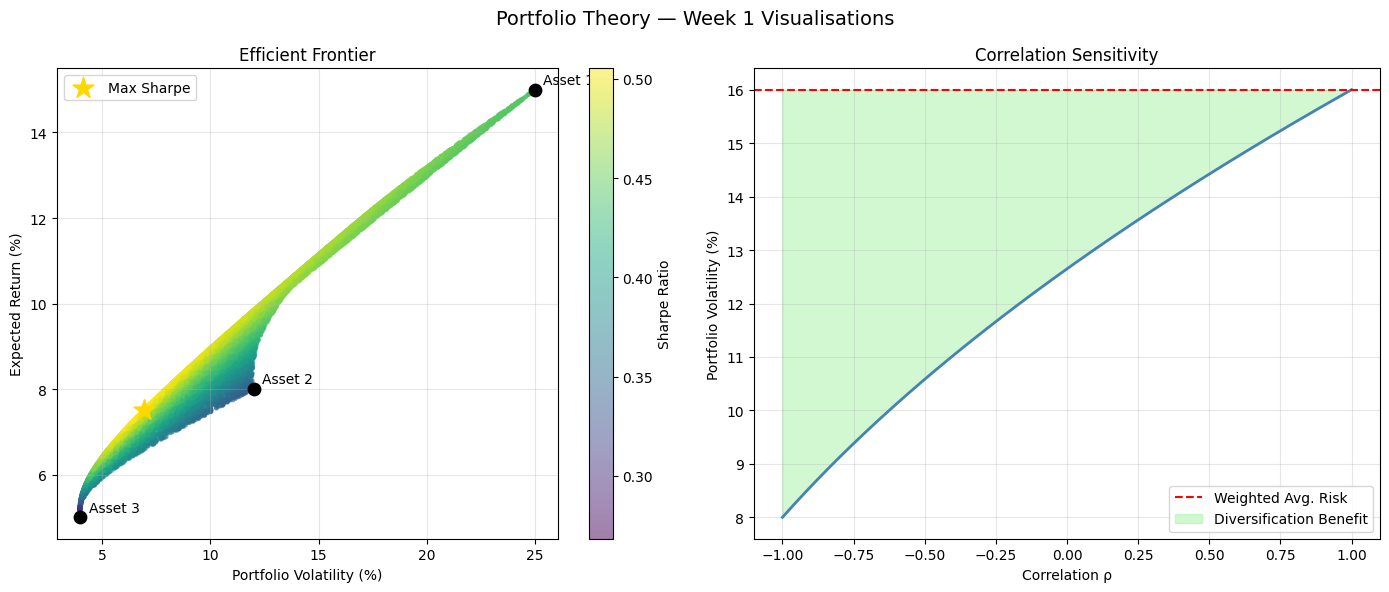

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 3-asset parameters from Q6
mu    = np.array([0.15, 0.08, 0.05])
sigma = np.array([0.25, 0.12, 0.04])
rho   = np.array([[1.0,0.4,0.1],[0.4,1.0,0.2],[0.1,0.2,1.0]])
Sigma = rho * np.outer(sigma, sigma)
Rf    = 0.04

# Simulate 20,000 random portfolios
W    = np.random.dirichlet(np.ones(3), 20000)
rets = W @ mu
vols = np.sqrt(np.einsum('ij,jk,ik->i', W, Sigma, W))
srs  = (rets - Rf) / vols

best = np.argmax(srs)

# Q12 setup for subplot 2
mu1,mu2,s1,s2,w1,w2 = 0.12,0.06,0.20,0.10,0.6,0.4
rho_arr = np.linspace(-1, 1, 200)
sig_p   = np.sqrt(w1**2*s1**2 + w2**2*s2**2 + 2*w1*w2*rho_arr*s1*s2)
wav     = w1*s1 + w2*s2   # weighted average risk

# ── Figure ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Portfolio Theory — Week 1 Visualisations', fontsize=14)

# Subplot 1 — Efficient Frontier
sc = ax1.scatter(vols*100, rets*100, c=srs, cmap='viridis',
                 s=6, alpha=0.5)
plt.colorbar(sc, ax=ax1, label='Sharpe Ratio')

ax1.scatter(vols[best]*100, rets[best]*100,
            color='gold', marker='*', s=250, zorder=5,
            label='Max Sharpe')

tickers = ['Asset 1','Asset 2','Asset 3']
for i in range(3):
    ax1.scatter(sigma[i]*100, mu[i]*100,
                color='black', s=80, zorder=6)
    ax1.annotate(tickers[i], (sigma[i]*100, mu[i]*100),
                 textcoords='offset points', xytext=(6,4))

ax1.set_xlabel('Portfolio Volatility (%)')
ax1.set_ylabel('Expected Return (%)')
ax1.set_title('Efficient Frontier')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2 — Correlation Sensitivity
ax2.plot(rho_arr, sig_p*100, color='steelblue', lw=2)
ax2.axhline(wav*100, color='red', linestyle='--',
            label='Weighted Avg. Risk')

# Shade diversification benefit
ax2.fill_between(rho_arr, sig_p*100, wav*100,
                 where=(sig_p*100 < wav*100),
                 color='lightgreen', alpha=0.4,
                 label='Diversification Benefit')

ax2.set_xlabel('Correlation ρ')
ax2.set_ylabel('Portfolio Volatility (%)')
ax2.set_title('Correlation Sensitivity')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('week1_plots.png', dpi=150, bbox_inches='tight')
plt.show()
